# Notebook Purpose: Opening up bd2 detections by SNR. 1/27/2025 will look at True Positives and what human annotations overlapped with them

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [4]:
import convert_between_detector_file_formats as conversion

## Function and Constant Definitions

In [5]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
BD2_DETS_SAVE_DIR = Path(f'20250127__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

### Below are the functions used for converting between detector formats

In [6]:
def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

In [7]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [8]:
wav_filename = '20220826_070000'
site = FILE_SITES[wav_filename]
plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

In [9]:
snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF,2.567162,1.733019
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF,6.879404,3.773733
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF,7.902035,3.914858
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF,1.782390,4.046462
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF,1.514990,4.166985
...,...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF,9.656562,1787.779767
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF,6.562988,1787.964100
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165,1788.217133
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF,5.589297,1788.419000


In [10]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
bd2_file_all_dets

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
2,HF,0.001833,50250.0,48960.0,1.866691,0.0015,0.0099,47812,51961,Pipistrellus pipistrellus,0.029,0.035,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
3,LF,0.081633,21750.0,22080.0,4.325132,0.0685,0.0827,22890,27157,Nyctalus leisleri,0.015,0.026,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
5,HF,0.103000,78000.0,72960.0,0.030461,0.0805,0.1215,68437,83068,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
6,LF,0.126333,27750.0,24960.0,0.067604,0.1225,0.1320,25468,33966,Eptesicus serotinus,0.010,0.026,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
7,HF,0.250467,74250.0,72000.0,0.301496,0.2355,0.2747,68437,81583,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91444,LF,1794.795100,21000.0,20160.0,1.870791,1794.7905,1794.8039,18593,23668,Nyctalus noctula,0.019,0.044,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
91445,LF,1794.872400,28500.0,24000.0,0.519903,1794.8715,1794.8781,24609,37378,Plecotus austriacus,0.020,0.040,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
91446,LF,1794.920500,12750.0,12480.0,11.896093,1794.9185,1794.9275,12578,19181,Nyctalus leisleri,0.018,0.024,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
91450,LF,1794.956833,21750.0,22080.0,1.793079,1794.9505,1794.9610,22031,27451,Nyctalus leisleri,0.011,0.031,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [11]:
bd2_human_df_file_LF = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
lf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='LF'].copy()

bd2_human_df_file_HF = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()
hf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='HF'].copy()

lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(bd2_human_df_file_LF, lf_bd2_file_all_dets)
hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(bd2_human_df_file_HF, hf_bd2_file_all_dets)

In [12]:
lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
print(len(lf_human_true_positives), len(lf_bd2_false_negatives), len(lf_bd2_true_positives), len(lf_bd2_false_positives))

1086 52 1098 28685


In [13]:
hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
print(len(hf_human_true_positives), len(hf_bd2_false_negatives), len(hf_bd2_true_positives), len(hf_bd2_false_positives))

3227 41 3230 19706


In [18]:
all_groups_bd2_true_positives = pd.concat([lf_bd2_true_positives, hf_bd2_true_positives])
all_groups_bd2_true_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
1495,LF,30.788267,24750.0,24960.0,1.580216,30.7805,30.7954,23750,29173,Nyctalus leisleri,0.026,0.071,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
1519,LF,31.196967,24750.0,24000.0,1.052236,31.1865,31.2022,23750,29512,Nyctalus leisleri,0.138,0.322,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
1556,LF,31.769033,24750.0,24960.0,1.232003,31.7585,31.7753,24609,29107,Nyctalus leisleri,0.103,0.242,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
1592,LF,32.199700,22500.0,23040.0,0.781188,32.1895,32.2008,23750,30161,Nyctalus leisleri,0.017,0.049,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
1632,LF,32.622300,26250.0,25920.0,5.033592,32.6175,32.6342,24609,28640,Nyctalus leisleri,0.365,0.571,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91137,HF,1787.779767,39750.0,39360.0,9.656562,1787.7745,1787.7849,37500,46675,Pipistrellus nathusii,0.492,0.587,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
91142,HF,1787.964100,40500.0,40320.0,6.562988,1787.9595,1787.9694,37500,45913,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
91155,HF,1788.217133,40500.0,41280.0,8.990165,1788.2125,1788.2212,39218,48186,Pipistrellus nathusii,0.431,0.544,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
91165,HF,1788.419000,41250.0,41280.0,5.583953,1788.4135,1788.4225,40078,49982,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


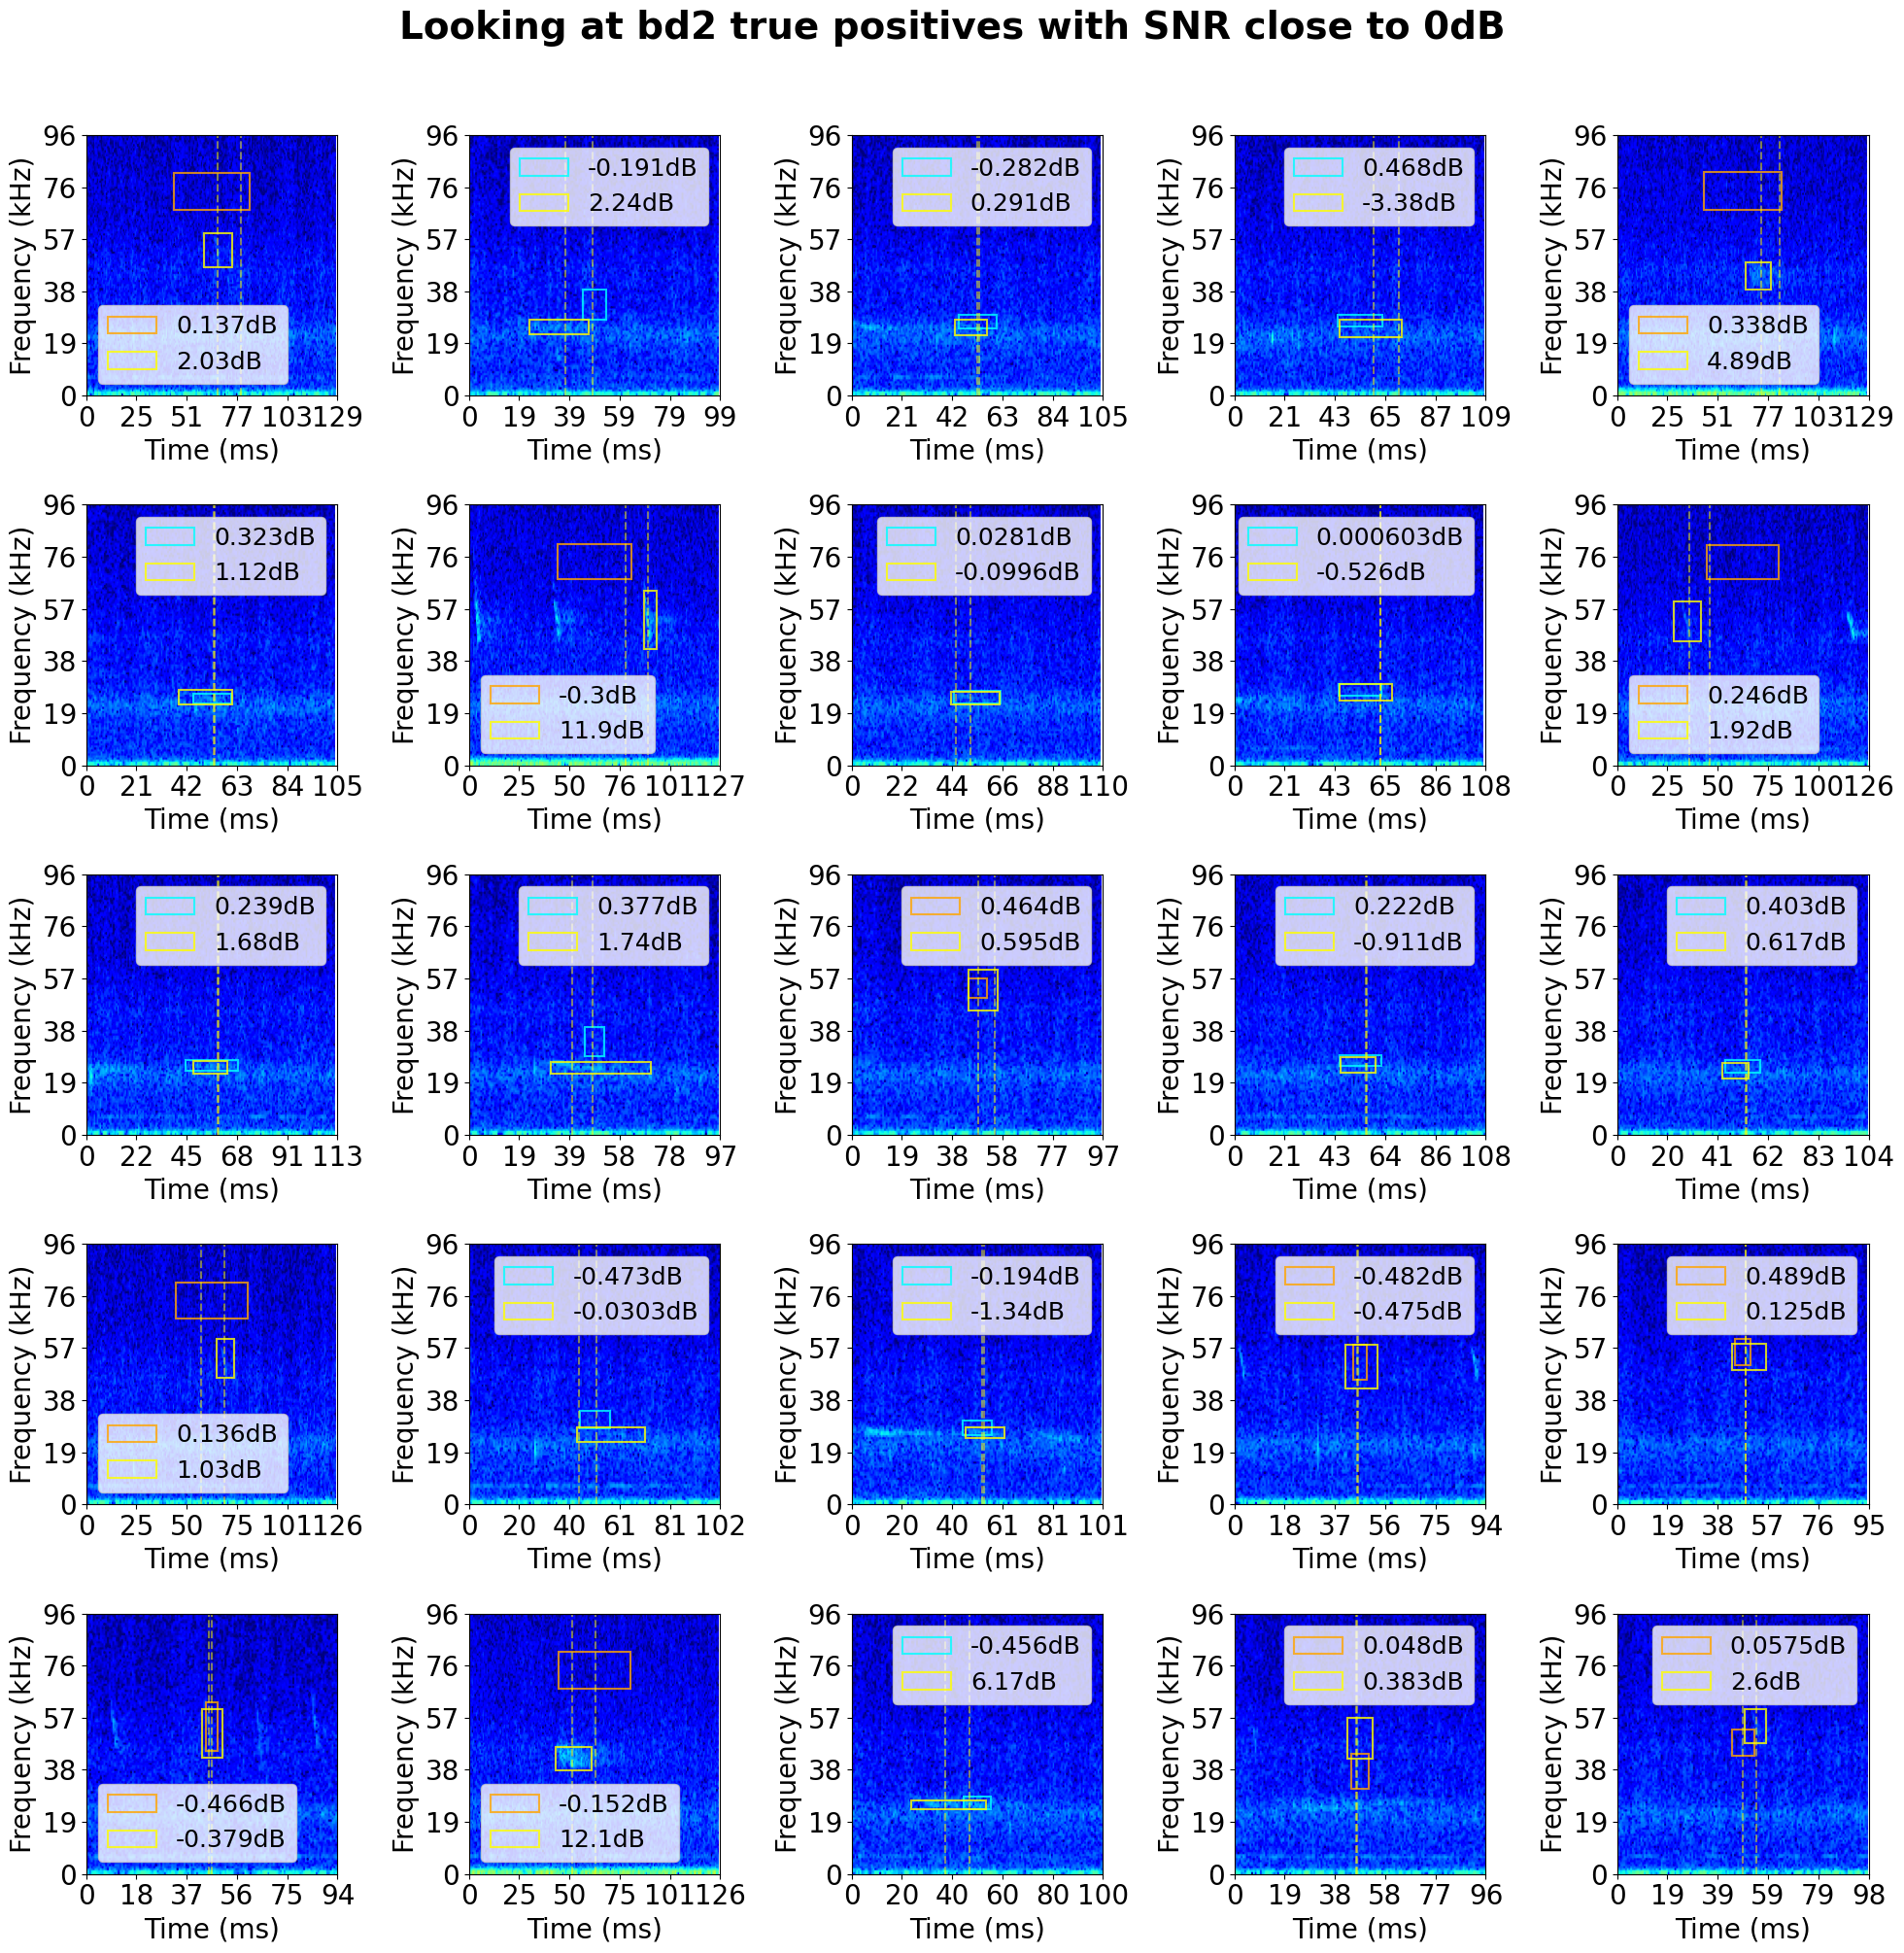

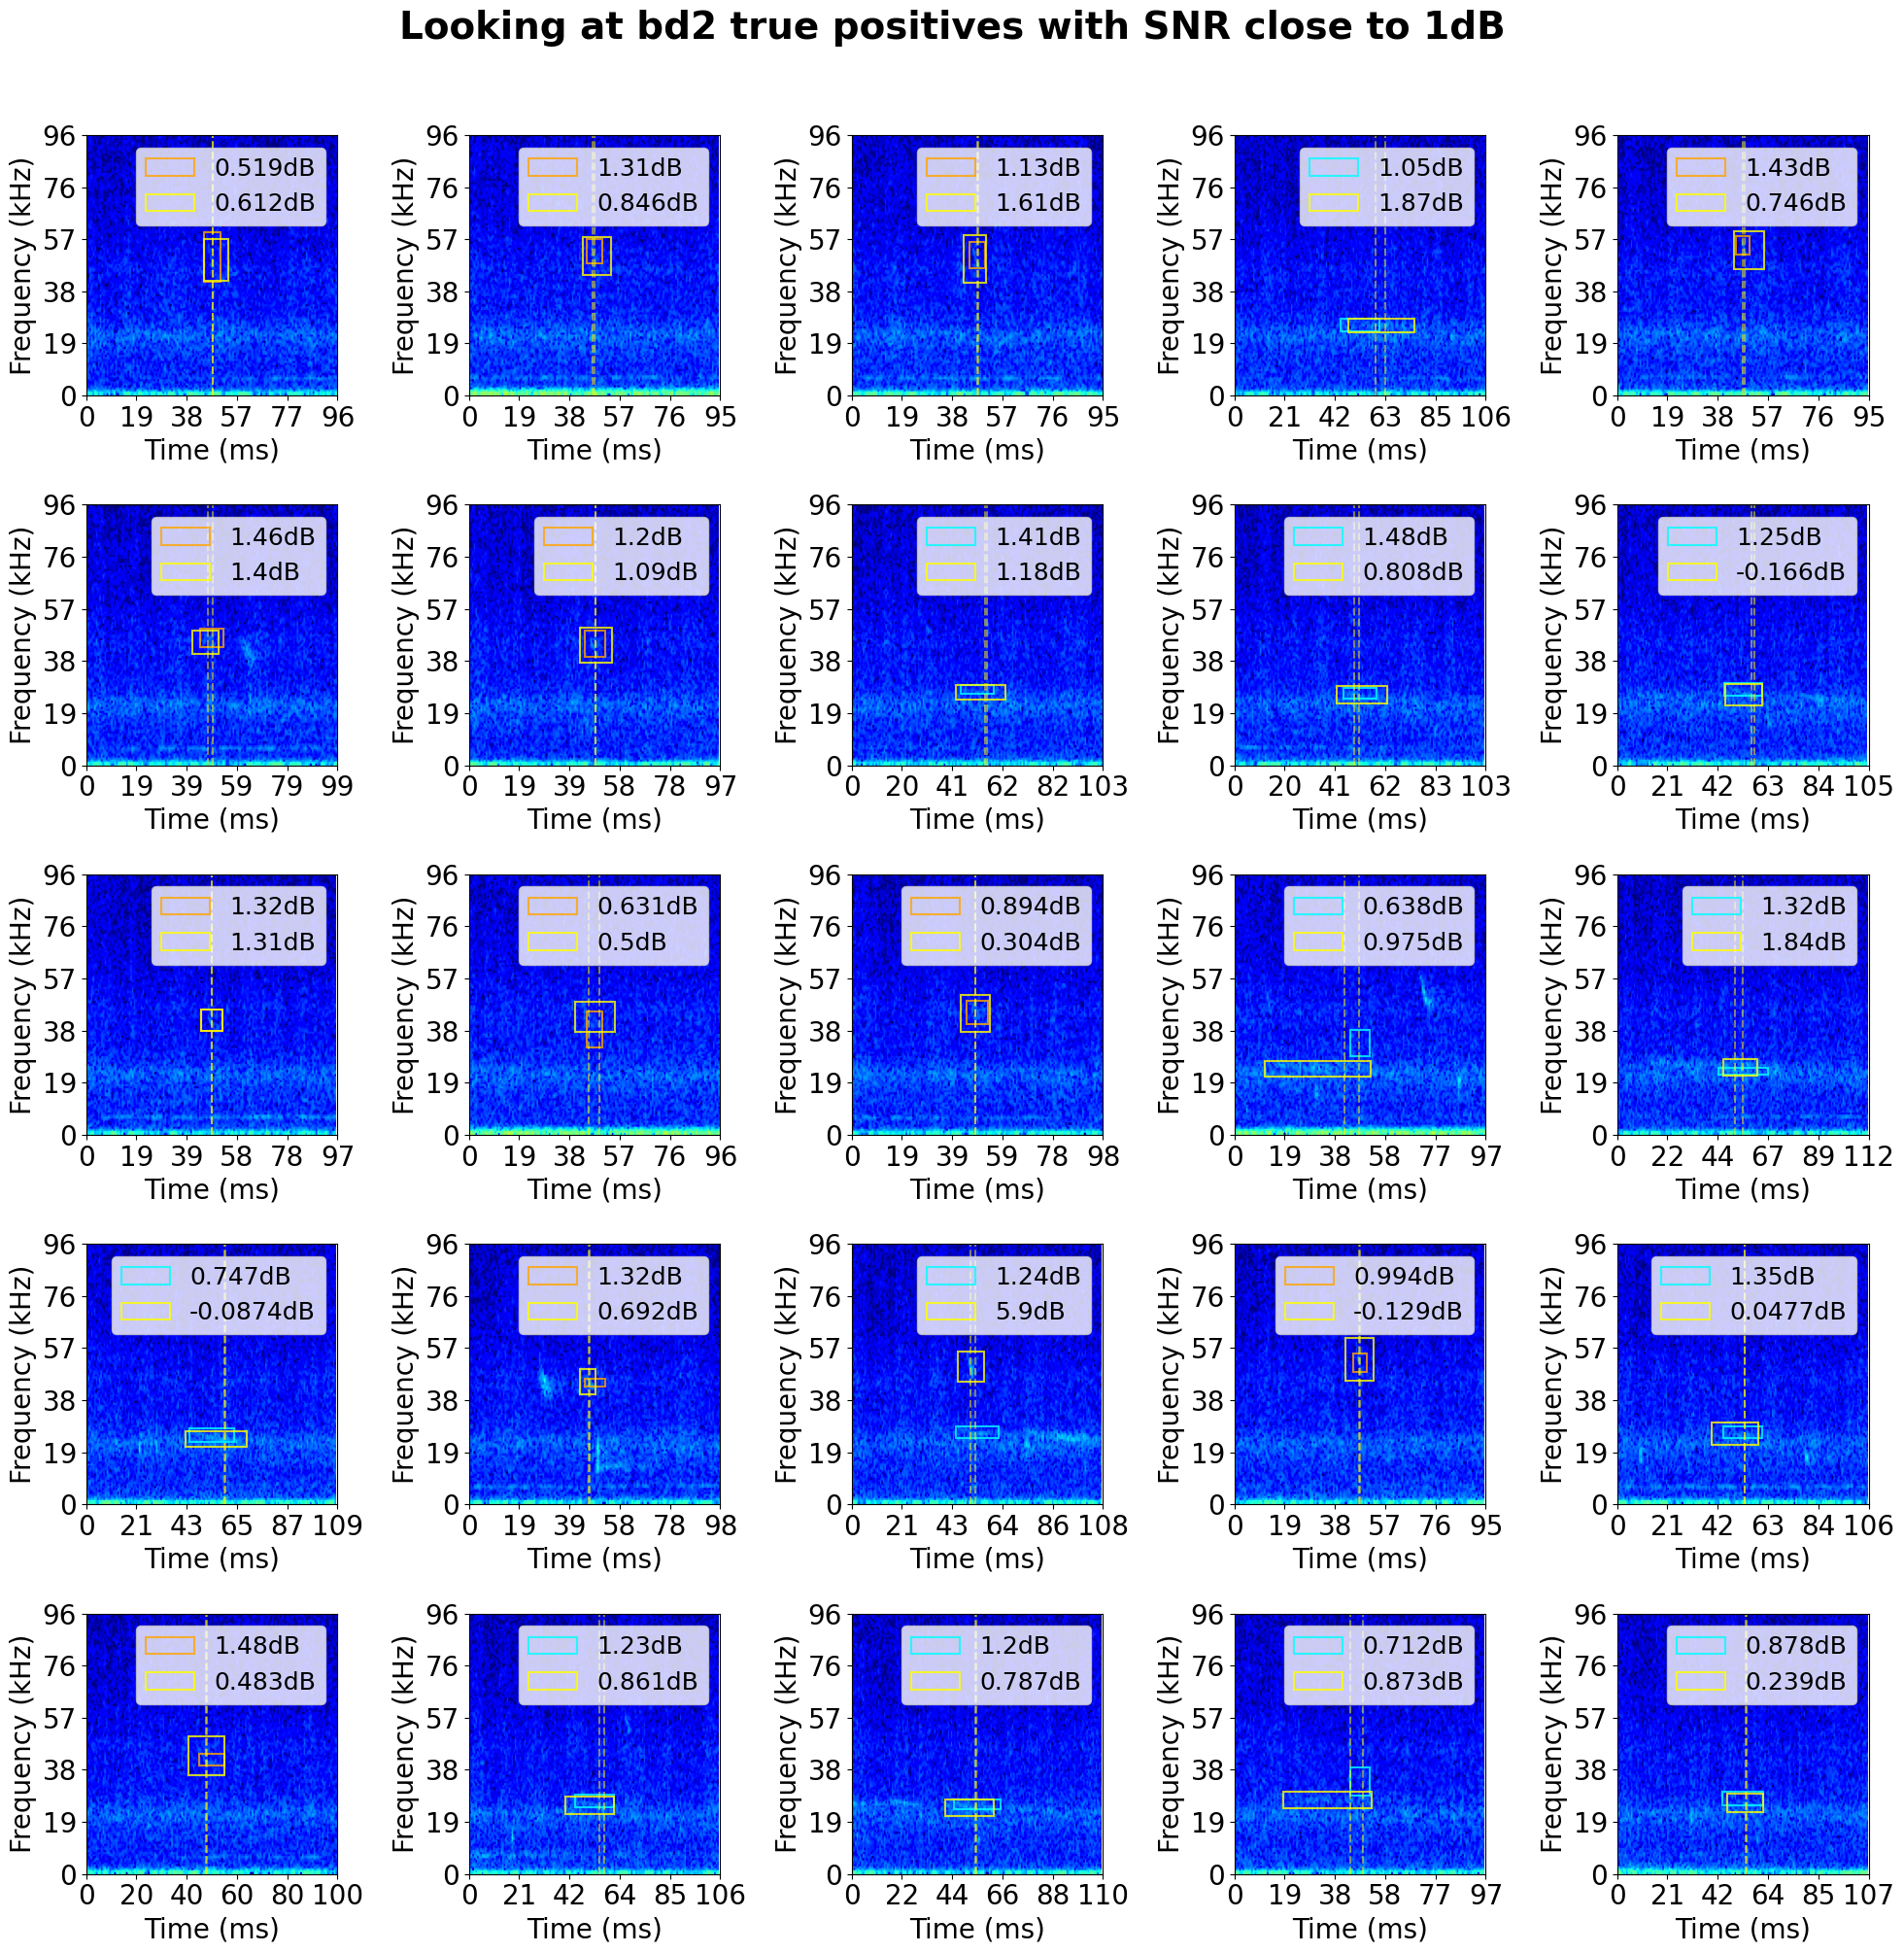

In [ ]:
for snr_threshold in np.arange(0, 11, 1):
    snrbased_selections = all_groups_bd2_true_positives[np.isclose(all_groups_bd2_true_positives['SNR'], snr_threshold, atol=0.5)].sample(n=25).reset_index(drop=True).copy()
    plt.figure(figsize=(4*5, 5*4))
    plt.rcParams.update({'font.size': 20})
    plt.suptitle(f'Looking at bd2 true positives with SNR close to {snr_threshold}dB', y=1.01, fontsize=28, fontweight='bold')
    for i, sel_ind in enumerate((snrbased_selections.index).values):
        plt.subplot(5,5,i+1)
        selection_row = snrbased_selections.iloc[sel_ind]
        file_name = f'{wav_filename}.WAV'
        file_path = Path(RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR) / file_name
        audio_file = sf.SoundFile(file_path)
        fs = audio_file.samplerate

        start = selection_row['start_time']-0.045
        audio_file.seek(int(fs*(start)))
        duration = (selection_row['end_time']-selection_row['start_time'])+0.09
        audio_seg = audio_file.read(int(fs*duration))

        plt.specgram(audio_seg, NFFT=256, Fs=fs, cmap='jet', vmin=-120, vmax=0)

        ax = plt.gca()
        rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                        (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8, label=f'{selection_row["SNR"]:.3}dB')
        ax.add_patch(rect)
        ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='yellow', alpha=0.5)

        human_dets_in_window = bd2_human_df_file[(bd2_human_df_file['start_time']>=start)&(bd2_human_df_file['end_time']<=(start+duration))]
        closest_ind = np.abs((human_dets_in_window['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).argmin()
        human_det = human_dets_in_window.iloc[closest_ind]
        rect = patches.Rectangle(((human_det['start_time'] - start), human_det['low_freq']), 
                        (human_det['end_time'] - human_det['start_time']), (human_det['high_freq'] - human_det['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8, label=f'{human_det["adityas_method_snr_dB"]:.3}dB')
        ax.add_patch(rect)
        ax.axvline(x=human_det['peak_frequency_time']-start, linestyle='dashed', color='yellow', alpha=0.5)
        plt.xticks(ticks=np.linspace(0, duration, 6),labels=(1000*np.linspace(0, duration, 6)).astype(int))
        plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
        plt.ylabel("Frequency (kHz)")
        plt.xlabel("Time (ms)")
        plt.legend(fontsize=18)

    plt.tight_layout()
    plt.show()